## Import das bibliotecas

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torchvision.models as models
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import optuna
from fvcore.nn import FlopCountAnalysis
from plotly.io import show
import os
from PIL import Image
import json
from dataset_utils import RaabinDataset
from pathlib import Path
from datetime import datetime
from preprocessing_utils import AspectPreservingResizeAndPad, ApplyCLAHE


### Configurando variáveis de ambiente e execução

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
NUM_WORKERS = 1
PERSISTENT_WORKERS = False
NJOBS = 1
NUM_TRIALS = 30
DIFF_THRESHOLD = 0.0

# === Persistência do Optuna ===
STUDY_NAME = "raabin_wbc_cnn_optimization"
STORAGE_DIR = Path("./optuna_studies")
STORAGE_DIR.mkdir(exist_ok=True)
DATABASE_PATH = f"sqlite:///{STORAGE_DIR}/optuna_study.db"
MODELS_DIR = STORAGE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
RESUME_STUDY = True  # Set to False se quiser começar novo estudo
LOGS_FILE = STORAGE_DIR / "trials_log.json"

In [4]:
# Reproducibility
SEED = 26
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import numpy as np
import random
np.random.seed(SEED)
random.seed(SEED)

## Preparação do dataset

### Funções de carregamento, split, e plot

In [5]:
CLASSES_DO_PROJETO = ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
MEAN = torch.tensor([0.7043, 0.5391, 0.5886])
STD = torch.tensor([0.1623, 0.1899, 0.0971])
IMG_HEIGHT = 575
IMG_WIDTH = 575
transform_train = v2.Compose([v2.ToImage(),
                              AspectPreservingResizeAndPad(target_size=IMG_HEIGHT, fill=255),
                              ApplyCLAHE(clip_limit=2.0),
                              v2.ToDtype(dtype=torch.float32, scale=True),
                              v2.Normalize(mean=MEAN, std=STD)])
transform_test = v2.Compose([v2.ToImage(),
                             AspectPreservingResizeAndPad(target_size=IMG_HEIGHT, fill=255),
                             ApplyCLAHE(clip_limit=2.0),
                             v2.ToDtype(dtype=torch.float32, scale=True),
                             v2.Normalize(mean=MEAN, std=STD)])


In [6]:
from dataset_utils import RaabinDataset


def split_train_val_dataset(dataset, val_size, random_state=42):
    labels = np.asarray([target for _, target in dataset.samples], dtype=np.int64)
    indices = np.arange(len(dataset.samples))
    train_idx, val_idx = train_test_split(
        indices, 
        test_size=val_size, 
        random_state=random_state, 
        stratify=labels)
    return Subset(dataset, train_idx), Subset(dataset, val_idx)
from preprocessing_utils import AspectPreservingResizeAndPad, ApplyCLAHE


In [7]:
def calcular_media_std(loader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in loader:
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data ** 2, dim=[0, 2, 3])
        num_batches += 1
        
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5
    return mean, std


In [8]:
def denormalize_image(img):
    mean = MEAN.to(img.device).view(3, 1, 1)
    std = STD.to(img.device).view(3, 1, 1)
    return img * std + mean

In [9]:
def plot_images(data, class_names=None, undo_norm=True):
    img, label = data

    if undo_norm:
        img = denormalize_image(img)

    img = img.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    label_idx = int(label.item()) if torch.is_tensor(label) else int(label)
    if class_names is not None:
        title = class_names[label_idx]
    else:
        title = str(label_idx)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Label: {title}")
    plt.axis("off")
    plt.show()


### execução

In [10]:
train_dataset = RaabinDataset(root_dir='./../datasets/raabin_wbc/Train', class_list=CLASSES_DO_PROJETO, transform=transform_train)
testA_dataset = RaabinDataset(root_dir='./../datasets/raabin_wbc/Test-A', class_list=CLASSES_DO_PROJETO, transform=transform_test)
testB_dataset = RaabinDataset(root_dir='./../datasets/raabin_wbc/Test-B', class_list=CLASSES_DO_PROJETO, transform=transform_test)

In [11]:
print(f'Tamanho do dataset de treino: {len(train_dataset)} amostras')
print(f'Tamanho do dataset de teste A: {len(testA_dataset)} amostras')
print(f'Tamanho do dataset de teste B: {len(testB_dataset)} amostras')

Tamanho do dataset de treino: 10175 amostras
Tamanho do dataset de teste A: 4339 amostras
Tamanho do dataset de teste B: 2119 amostras


In [12]:
train_split_dataset, val_dataset = split_train_val_dataset(train_dataset, val_size=(3175/10175), random_state=SEED)
print(f'Tamanho do dataset de treino após split: {len(train_split_dataset)} amostras')
print(f'Tamanho do dataset de validação: {len(val_dataset)} amostras')

Tamanho do dataset de treino após split: 6999 amostras
Tamanho do dataset de validação: 3176 amostras


In [13]:
IMG_HEIGHT = train_split_dataset[2][0].shape[1]
IMG_WIDTH = train_split_dataset[2][0].shape[2]
print(f'Tamanho das imagens: {IMG_HEIGHT}x{IMG_WIDTH}')

Tamanho das imagens: 575x575


In [14]:
temp_loader = DataLoader(train_split_dataset, batch_size=64, shuffle=False)

In [15]:
resultado = calcular_media_std(temp_loader)
print(f"Média: {resultado[0]}, DP: {resultado[1]}")

Média: tensor([-7.0422e-06,  1.3982e-04, -2.0843e-06]), DP: tensor([1.0003, 1.0003, 1.0005])


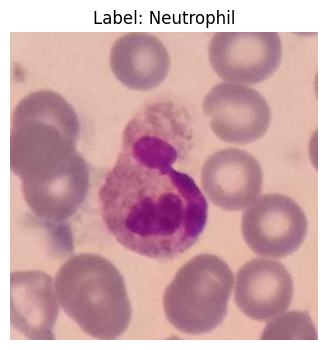

In [16]:
plot_images(train_split_dataset[0], class_names=CLASSES_DO_PROJETO, undo_norm=True)

## EDA

### Funções de plot

In [17]:
# mapear a distribuição das classes no dataset de treino
def show_class_distribution(dataloader: torch.utils.data.DataLoader, class_names: list, title='Distribuição das Classes no Dataset de Treino'):
    labels = [label.item() for _, target in dataloader for label in target]    
    class_counts = np.bincount(labels)
    print(f"Total de amostras: {len(labels)}")
    print(f"Contagem por classe: {dict(zip(class_names, class_counts))}")
    print(f"=" * 40)
    plt.figure(figsize=(8, 5))
    plt.bar(class_names, class_counts, color='skyblue')
    plt.xlabel('Classes')
    plt.ylabel('Número de Amostras')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [18]:
def undersample_dataset(dataset, dataloader, class_list, tamanho_undersample):
    labels = [label.item() for _, target in dataloader for label in target]

    samples_per_class = tamanho_undersample // len(class_list)
    index_list = []
    for class_idx in range(len(class_list)):
        class_indices = [i for i, label in enumerate(labels) if label == class_idx]
        if len(class_indices) > samples_per_class:
            selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)
        else:
            selected_indices = class_indices
        index_list.extend(selected_indices)
    if len(index_list) < tamanho_undersample:
        remaining_indices = list(set(range(len(dataset))) - set(index_list))
        additional_indices = np.random.choice(remaining_indices, tamanho_undersample - len(index_list), replace=False)
        index_list.extend(additional_indices)
    return Subset(dataset, index_list)



### execução

Total de amostras: 6999
Contagem por classe: {'Basophil': np.int64(146), 'Eosinophil': np.int64(512), 'Lymphocyte': np.int64(1669), 'Monocyte': np.int64(386), 'Neutrophil': np.int64(4286)}


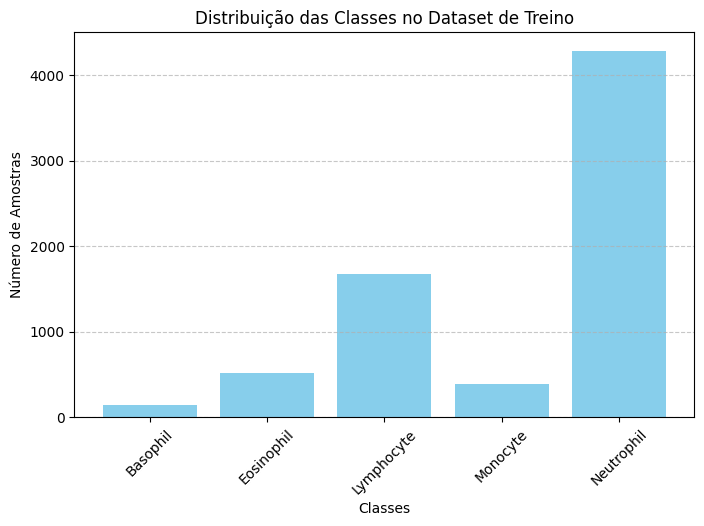

In [69]:
show_class_distribution(temp_loader, CLASSES_DO_PROJETO)

In [70]:
train_reduced_dataset = undersample_dataset(train_split_dataset, temp_loader, CLASSES_DO_PROJETO, tamanho_undersample=2000)
print(f'Tamanho do dataset de treino reduzido: {len(train_reduced_dataset)} amostras')

Tamanho do dataset de treino reduzido: 2000 amostras


In [71]:
val_reduced_dataset = undersample_dataset(val_dataset, DataLoader(val_dataset, batch_size=64, shuffle=False), CLASSES_DO_PROJETO, tamanho_undersample=1000)
print(f'Tamanho do dataset de validação reduzido: {len(val_reduced_dataset)} amostras')

Tamanho do dataset de validação reduzido: 1000 amostras


Total de amostras: 2000
Contagem por classe: {'Basophil': np.int64(146), 'Eosinophil': np.int64(409), 'Lymphocyte': np.int64(463), 'Monocyte': np.int64(386), 'Neutrophil': np.int64(596)}


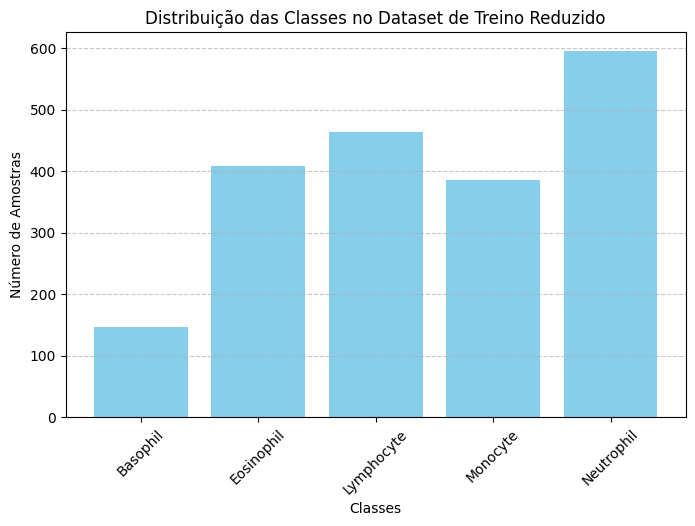

In [72]:
show_class_distribution(DataLoader(train_reduced_dataset, batch_size=64, shuffle=False), CLASSES_DO_PROJETO, title='Distribuição das Classes no Dataset de Treino Reduzido')

Total de amostras: 1000
Contagem por classe: {'Basophil': np.int64(66), 'Eosinophil': np.int64(202), 'Lymphocyte': np.int64(241), 'Monocyte': np.int64(175), 'Neutrophil': np.int64(316)}


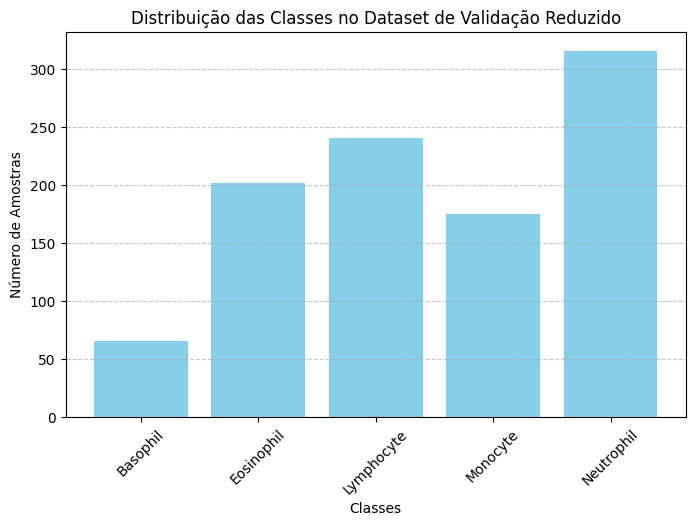

In [73]:
show_class_distribution(DataLoader(val_reduced_dataset, batch_size=64, shuffle=False), CLASSES_DO_PROJETO, title='Distribuição das Classes no Dataset de Validação Reduzido')

In [74]:
del temp_loader

## Códigos para treinamento, avaliação e plot

In [19]:
def f1_score_macro(y_true, y_pred):
    return metrics.f1_score(y_true, y_pred, average='macro')

In [20]:
# função para avaliar o modelo no conjunto de teste
def evaluate_model(model, test_dataloader, metric_fn=metrics.accuracy_score, device=device):
    """
    Avalia o modelo em um conjunto de teste.
    
    Args:
        model: Modelo CNN
        test_dataloader: DataLoader com dados de teste
        metric_fn: Função de métrica (padrão: accuracy_score para classificação)
        device: Device (CPU ou CUDA)
    
    Returns:
        metric_val: Valor da métrica calculada
    """
    model.eval()
    y_true = []
    y_pred_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            
            # Para classificação: converter logits para índices de classe
            predictions = torch.argmax(outputs, dim=1)
            
            y_true.extend(y_batch.detach().cpu().numpy())
            y_pred_list.extend(predictions.detach().cpu().numpy())
    
    # Calcular métrica
    metric_val = metric_fn(y_true, y_pred_list)
    return metric_val

In [21]:
def train_model(model, train_dataloader, val_dataloader, loss_fn, optimizer, num_epochs, patience, metric_fn=None, device=device, verbose=False):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history_train_loss = []
    history_val_loss = []
    history_val_metric = []

    if verbose:
        print(f'Starting training for {num_epochs} epochs...')

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        history_train_loss.append(avg_train_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}')

        # validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history_val_loss.append(avg_val_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}')

        # avaliando a métrica de validação
        if metric_fn is not None:
            metric_val = evaluate_model(model, val_dataloader, metric_fn=metric_fn, device=device)
            history_val_metric.append(metric_val)
            if verbose and epoch % 5 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Validation Metric: {metric_val:.4f}')

        # critério de parada
        if (avg_val_loss + DIFF_THRESHOLD) < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return history_train_loss, history_val_loss, history_val_metric

In [22]:
def plot_loss_graph(history_train_loss, history_val_loss, history_val_metric):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_train_loss, label='Train Loss')
    ax1.plot(history_val_loss, label='Val Loss')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend()

    if history_val_metric:
        ax2.plot(history_val_metric, label='Val F1 Score', color='green')
        ax2.set_xlabel('Epochs'); ax2.set_ylabel('F1 Score')
        ax2.set_title('Validation F1 Score'); ax2.legend()
    plt.tight_layout(); plt.show()

In [23]:
def plot_confusion_matrix(model, dataloader, class_names, device=device):
    model.eval()
    y_true = []
    y_pred_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)
            
            y_true.extend(y_batch.detach().cpu().numpy())
            y_pred_list.extend(predictions.detach().cpu().numpy())
    
    cm = metrics.confusion_matrix(y_true, y_pred_list)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title('Confusion Matrix')
    plt.show()

In [24]:
def print_percentage_error_classification(model, dataloader, class_names, device=device):
    model.eval()
    y_true = []
    y_pred_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)
            
            y_true.extend(y_batch.detach().cpu().numpy())
            y_pred_list.extend(predictions.detach().cpu().numpy())
    
    cm = metrics.confusion_matrix(y_true, y_pred_list)
    for i, class_name in enumerate(class_names):
        total = cm[i].sum()
        correct = cm[i][i]
        error_percentage = (total - correct) / total * 100 if total > 0 else 0
        print(f'Classe: {class_name}, Erro: {error_percentage:.4f}%')


## CNN

### Funções para criação da CNN

In [25]:
map_activation_functions = {
    'relu': nn.ReLU,
    'sigmoid': nn.Sigmoid,
    'tanh': nn.Tanh,
    'leaky_relu': nn.LeakyReLU,
}
map_optimizers = {
    'adam': torch.optim.Adam,
    'sgd': torch.optim.SGD,
    'rmsprop': torch.optim.RMSprop,
    'adagrad': torch.optim.Adagrad
}
def get_activation_function(name):
    return map_activation_functions[name]()

In [26]:
class CNNParameters:
    def __init__(self, num_conv_layers, stride_conv_layers, input_channels, out_channels_list, use_pooling,
                 padding_conv_layer, dilatation, bias, kernel_size, kernel_stride,
                 kernel_padding, kernel_dilatation, activation_function_conv, fully_connected_layers_list,
                 activation_function_fully_connected, dropout_rate_fully_connected, dropout_rate_conv, output_size_fully_connected,
                 image_size_height, image_size_width, use_normalization_cnn, use_normalization_fc
                 ):
        
        # cnn parameters
        self.num_conv_layers = num_conv_layers
        self.stride_conv_layers = stride_conv_layers
        self.input_channels = input_channels
        self.out_channels_list = out_channels_list
        self.dropout_rate_conv = dropout_rate_conv
        self.padding_conv_layer = padding_conv_layer
        self.dilatation = dilatation
        self.bias = bias
        self.activation_function_conv = activation_function_conv
        self.use_normalization = use_normalization_cnn

        # polling parameters
        self.use_pooling = use_pooling
        self.kernel_size = kernel_size
        self.kernel_stride = kernel_stride
        self.kernel_padding = kernel_padding
        self.kernel_dilatation = kernel_dilatation

        # fully connected layers parameters
        self.fully_connected_layers_list = fully_connected_layers_list
        self.activation_function_fully_connected = activation_function_fully_connected
        self.dropout_rate_fully_connected = dropout_rate_fully_connected
        self.output_size_fully_connected = output_size_fully_connected
        self.use_normalization_fc = use_normalization_fc
        

        #flatten size
        self.image_size_height = image_size_height
        self.image_size_width = image_size_width
        self.image_size_height_output = 0
        self.image_size_width_output = 0
        self.image_size_height_output, self.image_size_width_output = self._calculate_output_size(image_size_height, image_size_width)
        self.flatten_size = self.image_size_height_output * self.image_size_width_output * self.out_channels_list[-1]

    def _calculate_output_size(self, input_size_height, input_size_width):
        output_size_height = input_size_height
        output_size_width = input_size_width
        for i in range(self.num_conv_layers):
            output_size_height = (output_size_height + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            output_size_width = (output_size_width + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            if self.use_pooling:
                output_size_height = (output_size_height + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
                output_size_width = (output_size_width + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
        return output_size_height, output_size_width

In [27]:
class CNN(nn.Module):
    def __init__(self, cnn_parameters: CNNParameters):
        super(CNN, self).__init__()
        self.cnn_parameters = cnn_parameters

        layers = []

        for i in range(self.cnn_parameters.num_conv_layers):
            layers.append(nn.Conv2d(in_channels=self.cnn_parameters.input_channels if i == 0 else self.cnn_parameters.out_channels_list[i-1],
                                    out_channels=self.cnn_parameters.out_channels_list[i],
                                    kernel_size=self.cnn_parameters.kernel_size,
                                    stride=self.cnn_parameters.stride_conv_layers,
                                    padding=self.cnn_parameters.padding_conv_layer,
                                    dilation=self.cnn_parameters.dilatation,
                                    bias=self.cnn_parameters.bias))
            layers.append(get_activation_function(self.cnn_parameters.activation_function_conv))

            if self.cnn_parameters.use_normalization:
                layers.append(nn.BatchNorm2d(self.cnn_parameters.out_channels_list[i], device=device))

            if self.cnn_parameters.dropout_rate_conv > 0:
                layers.append(nn.Dropout2d(self.cnn_parameters.dropout_rate_conv))

            if self.cnn_parameters.use_pooling:
                layers.append(nn.MaxPool2d(kernel_size=self.cnn_parameters.kernel_size,
                                           stride=self.cnn_parameters.kernel_stride,
                                           padding=self.cnn_parameters.kernel_padding,
                                           dilation=self.cnn_parameters.kernel_dilatation))
        
        self.conv_layers = nn.Sequential(*layers)
        
        fully_connected_layers = []
        input_size_fully_connected = cnn_parameters.flatten_size

        for output_size in self.cnn_parameters.fully_connected_layers_list:
            fully_connected_layers.append(nn.Linear(input_size_fully_connected, output_size))
            fully_connected_layers.append(get_activation_function(self.cnn_parameters.activation_function_fully_connected))
            if self.cnn_parameters.use_normalization_fc:
                fully_connected_layers.append(nn.BatchNorm1d(output_size, device=device))
            if self.cnn_parameters.dropout_rate_fully_connected > 0:
                fully_connected_layers.append(nn.Dropout(self.cnn_parameters.dropout_rate_fully_connected))
            input_size_fully_connected = output_size
        
        fully_connected_layers.append(nn.Linear(input_size_fully_connected, self.cnn_parameters.output_size_fully_connected))
        self.fully_connected_layers = nn.Sequential(*fully_connected_layers)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.flatten(start_dim=1)
        x = self.fully_connected_layers(x)
        return x
            
        

In [28]:
def get_or_create_study(study_name, storage_db, resume=True, seed=None):
    """
    Carrega um estudo existente ou cria um novo.
    
    Args:
        study_name: Nome único do estudo
        storage_db: URL do banco SQLite (ex: sqlite:///path/study.db)
        resume: Se True, retoma estudo existente; se False, cria novo
        seed: Seed para TPE sampler
    
    Returns:
        study: Optuna Study object
    """
    sampler = optuna.samplers.TPESampler(seed=seed)
    
    try:
        # Tenta carregar estudo existente
        study = optuna.load_study(
            study_name=study_name,
            storage=storage_db,
            sampler=sampler
        )
        if resume:
            print(f"✓ Estudo '{study_name}' carregado. Trials completados: {len(study.trials)}")
            return study
        else:
            # Se resume=False, apagar e criar novo
            optuna.delete_study(study_name=study_name, storage=storage_db)
            print(f"✓ Estudo anterior deletado. Criando novo.")
    except:
        pass
    
    # Criar novo estudo
    study = optuna.create_study(
        study_name=study_name,
        storage=storage_db,
        directions=['maximize', 'minimize'],
        sampler=sampler,
        load_if_exists=True,
    )
    print(f"✓ Novo estudo '{study_name}' criado")
    return study

def log_trial_result(trial_number, trial_params, f1_score, flops, trial_exception=None):
    """Salva resultado de cada trial em JSON para auditoria."""
    try:
        if LOGS_FILE.exists():
            with open(LOGS_FILE, 'r') as f:
                logs = json.load(f)
        else:
            logs = []
        
        trial_log = {
            "trial_id": trial_number,
            "timestamp": datetime.now().isoformat(),
            "f1_score": float(f1_score) if f1_score is not None else None,
            "flops": float(flops) if flops != float('inf') else "inf",
            "exception": str(trial_exception) if trial_exception else None,
            "hyperparams": trial_params
        }
        logs.append(trial_log)
        
        with open(LOGS_FILE, 'w') as f:
            json.dump(logs, f, indent=2)
    except Exception as e:
        print(f"Erro ao salvar log de trial: {e}")

def save_trial_model(trial, model, cnn_params):
    """Salva modelo de um trial bem-sucedido."""
    try:
        model_file = MODELS_DIR / f"trial_{trial.number}_model.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'trial_number': trial.number,
            'cnn_params': {
                'num_conv_layers': cnn_params.num_conv_layers,
                'out_channels_list': cnn_params.out_channels_list,
                'kernel_size': cnn_params.kernel_size,
                'activation_function_conv': cnn_params.activation_function_conv,
                'activation_function_fc': cnn_params.activation_function_fully_connected,
                'output_size': cnn_params.output_size_fully_connected,
            },
            'timestamp': datetime.now().isoformat()
        }, model_file)
        print(f"  → Modelo salvo: {model_file}")
    except Exception as e:
        print(f"  ⚠ Erro ao salvar modelo: {e}")

def print_study_summary():
    """Imprime resumo dos trials completados."""
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=DATABASE_PATH
    )
    
    print(f"\n{'='*60}")
    print(f"RESUMO DO ESTUDO: {STUDY_NAME}")
    print(f"{'='*60}")
    print(f"Total de trials: {len(study.trials)}")
    print(f"Trials completos: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
    print(f"Trials falhados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
def print_study_summary():
    """Imprime resumo dos trials completados."""
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=DATABASE_PATH
    )
    
    print(f"\n{'='*60}")
    print(f"RESUMO DO ESTUDO: {STUDY_NAME}")
    print(f"{'='*60}")
    print(f"Total de trials: {len(study.trials)}")
    print(f"Trials completos: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
    print(f"Trials falhados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
    # === CORREÇÃO PARA MULTI-OBJETIVO ===
    best_trials = study.best_trials
    if best_trials:
        print(f"\nMelhores trials (Fronteira de Pareto - F1-Score e FLOPs):")
        for i, trial in enumerate(best_trials):
            print(f"\n  [{i+1}] Trial ID: {trial.number}")
            print(f"      F1-Score: {trial.values[0]:.4f}")
            print(f"      FLOPs: {trial.values[1]:.2e}")
            print(f"      Hiperparâmetros:")
            for key, value in trial.params.items():
                print(f"        {key}: {value}")
    print(f"{'='*60}\n")

In [29]:
def create_cnn_model_and_dataloaders(cnn_parameters, train_data, test_data, val_data, batch_size):
    model = CNN(cnn_parameters)
    
    # Validar e configurar workers
    num_workers = NUM_WORKERS if NUM_WORKERS > 0 else 0
    persistent_workers = PERSISTENT_WORKERS if num_workers > 0 else False
    
    kwargs = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )
    
    if persistent_workers:
        kwargs['persistent_workers'] = True
        kwargs['prefetch_factor'] = 2
    
    train_dataloader = DataLoader(train_data, shuffle=True, **kwargs)
    test_dataloader = DataLoader(test_data, shuffle=False, **kwargs)
    val_dataloader = DataLoader(val_data, shuffle=False, **kwargs)
    
    return model, train_dataloader, test_dataloader, val_dataloader

In [30]:
def objective(trial):
    """
    Otimização com persistência de modelos e limpeza de memória.
    """
    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        num_conv_layers = trial.suggest_int('num_conv_layers', 3, 8)
        
        out_channels_list = []
        for i in range(num_conv_layers):
            out_channels = trial.suggest_categorical(f'out_channels_layer_{i}', [4, 8, 16, 32])
            out_channels_list.append(out_channels)

        kernel_size = trial.suggest_int('kernel_size', 3, 5)
        stride_conv = trial.suggest_categorical('stride_conv', [1, 2])
        padding_conv = trial.suggest_categorical('padding_conv', [0, 1, 2, 3, 4])
        dilatation = trial.suggest_categorical('dilatation', [1, 2, 3])
        bias = True

        use_pooling = True
        kernel_stride_pool = trial.suggest_categorical('kernel_stride_pool', [2, 3, 4, 5])
        kernel_padding_pool = 0
        kernel_dilatation_pool = 1

        activation_function_conv = trial.suggest_categorical('activation_function_conv', ['relu', 'leaky_relu', 'tanh'])
        use_dropout_conv = trial.suggest_categorical('use_dropout_conv', [True, False])
        dropout_rate_conv = trial.suggest_categorical('dropout_rate_conv', [0.2, 0.3, 0.4, 0.5, 0.6]) if use_dropout_conv else 0.0

        use_normalization_conv = trial.suggest_categorical('use_normalization_conv', [True, False])

        num_fc_layers = trial.suggest_int('num_fc_layers', 1, 3)
        fully_connected_layers_list = []
        for i in range(num_fc_layers):
            fc_units = trial.suggest_categorical(f'fc_units_{i}', [8, 16, 32, 64, 128, 256])
            fully_connected_layers_list.append(fc_units)

        activation_function_fc = trial.suggest_categorical('activation_function_fc', ['relu', 'leaky_relu', 'tanh', 'sigmoid'])
        use_dropout_fc = trial.suggest_categorical('use_dropout_fc', [True, False])
        dropout_rate_fc = trial.suggest_categorical('dropout_rate_fc', [0.2, 0.3, 0.4, 0.5, 0.6]) if use_dropout_fc else 0.0

        use_normalization_fc = trial.suggest_categorical('use_normalization_fc', [True, False])

        batch_size = trial.suggest_categorical('batch_size', [16, 32])
        learning_rate = trial.suggest_float('learning_rate', 3e-4, 5e-1, log=True)
        optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
        use_weight_decay = trial.suggest_categorical('use_weight_decay', [True, False])
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True) if use_weight_decay else 0.0

        num_epochs = 100000
        patience = 10

        image_size_height = IMG_HEIGHT
        image_size_width = IMG_WIDTH
        cnn_params = CNNParameters(
            num_conv_layers=num_conv_layers,
            stride_conv_layers=stride_conv,
            input_channels=3,
            out_channels_list=out_channels_list,
            use_pooling=use_pooling,
            padding_conv_layer=padding_conv,
            dilatation=dilatation,
            bias=bias,
            kernel_size=kernel_size,
            kernel_stride=kernel_stride_pool,
            kernel_padding=kernel_padding_pool,
            kernel_dilatation=kernel_dilatation_pool,
            activation_function_conv=activation_function_conv,
            fully_connected_layers_list=fully_connected_layers_list,
            activation_function_fully_connected=activation_function_fc,
            dropout_rate_fully_connected=dropout_rate_fc,
            dropout_rate_conv=dropout_rate_conv,
            output_size_fully_connected=len(CLASSES_DO_PROJETO),
            image_size_height=image_size_height,
            image_size_width=image_size_width,
            use_normalization_cnn=use_normalization_conv,
            use_normalization_fc=use_normalization_fc
        )

        if cnn_params.image_size_height_output <= 0 or cnn_params.image_size_width_output <= 0:
            return 0.0, float('inf')

        model, train_dataloader, test_dataloader, val_dataloader = create_cnn_model_and_dataloaders(
            cnn_params, train_reduced_dataset, testA_dataset, val_reduced_dataset, batch_size
        )
        model = model.to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer_cls = map_optimizers[optimizer_name]

        if optimizer_name == 'sgd':
            use_momentum = trial.suggest_categorical('use_momentum', [True, False])
            momentum = trial.suggest_float('momentum', 0.5, 0.9) if use_momentum else 0.0
            use_nesterov = trial.suggest_categorical('use_nesterov', [True, False]) if use_momentum else False
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay, nesterov=use_nesterov)
        elif optimizer_name == 'adam':
            use_betas = trial.suggest_categorical('use_betas', [True, False])
            if use_betas:
                beta1 = trial.suggest_float('beta1', 0.8, 0.99)
                beta2 = trial.suggest_float('beta2', 0.9, 0.999)
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=(beta1, beta2))
            else:
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        else:  # rmsprop
            use_momentum = trial.suggest_categorical('use_momentum', [True, False])
            momentum = trial.suggest_float('momentum', 0.5, 0.9) if use_momentum else 0.0
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

        history_train_loss, history_val_loss, history_val_metric = train_model(
            model,
            train_dataloader,
            val_dataloader,
            loss_fn,
            optimizer,
            num_epochs=num_epochs,
            patience=patience,
            metric_fn=f1_score_macro,
            device=device,
        )

        eval_metric = evaluate_model(model, val_dataloader, metric_fn=f1_score_macro, device=device)
        flops = FlopCountAnalysis(model.cpu(), torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).cpu()).total()

        # === NOVO: Salvar modelo e log ===
        save_trial_model(trial, model, cnn_params)
        log_trial_result(trial.number, trial.params, eval_metric, flops)
        
        # Limpeza de memória
        del model, train_dataloader, val_dataloader, test_dataloader, optimizer
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        return eval_metric, flops

    except Exception as e:
        print(f"Erro durante trial {trial.number}: {e}")
        log_trial_result(trial.number, {}, None, float('inf'), trial_exception=e)
        return 0.0, float('inf')

In [31]:
def load_model_for_trial(trial_number):
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=DATABASE_PATH
    )
    trial = study.trials[trial_number]
    model_file = MODELS_DIR / f"trial_{trial.number}_model.pth"
    if not model_file.exists():
        print(f"Modelo para trial {trial_number} não encontrado.")
        return None, None
    
    cnn_params = CNNParameters(
        num_conv_layers=trial.params['num_conv_layers'],
        stride_conv_layers=trial.params['stride_conv'],
        input_channels=3,
        out_channels_list=[trial.params[f'out_channels_layer_{i}'] for i in range(trial.params['num_conv_layers'])],
        use_pooling=True,
        padding_conv_layer=trial.params['padding_conv'],
        dilatation=trial.params['dilatation'],
        bias=True,
        kernel_size=trial.params['kernel_size'],
        kernel_stride=trial.params['kernel_stride_pool'],
        kernel_padding=0,
        kernel_dilatation=1,
        activation_function_conv=trial.params['activation_function_conv'],
        fully_connected_layers_list=[trial.params[f'fc_units_{i}'] for i in range(trial.params['num_fc_layers'])],
        activation_function_fully_connected=trial.params['activation_function_fc'],
        dropout_rate_fully_connected=trial.params['dropout_rate_fc'] if trial.params['use_dropout_fc'] else 0.0,
        dropout_rate_conv=trial.params['dropout_rate_conv'] if trial.params['use_dropout_conv'] else 0.0,
        output_size_fully_connected=len(CLASSES_DO_PROJETO),
        image_size_height=IMG_HEIGHT,
        image_size_width=IMG_WIDTH,
        use_normalization_cnn=trial.params['use_normalization_conv'],
        use_normalization_fc=trial.params['use_normalization_fc']
    )
    model = CNN(cnn_params)
    checkpoint = torch.load(model_file, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Modelo para trial {trial_number} carregado com sucesso.")
    print(model)
    return model


### execução

In [86]:
"""
# === Carregamento ou Criação do Estudo ===
study = get_or_create_study(
    study_name=STUDY_NAME,
    storage_db=DATABASE_PATH,
    resume=RESUME_STUDY,
    seed=SEED
)

print(f"\nIniciando otimização com {NUM_TRIALS} trials...\n")

# Executar otimização
study.optimize(objective, n_trials=NUM_TRIALS)
"""

'\n# === Carregamento ou Criação do Estudo ===\nstudy = get_or_create_study(\n    study_name=STUDY_NAME,\n    storage_db=DATABASE_PATH,\n    resume=RESUME_STUDY,\n    seed=SEED\n)\n\nprint(f"\nIniciando otimização com {NUM_TRIALS} trials...\n")\n\n# Executar otimização\nstudy.optimize(objective, n_trials=NUM_TRIALS)\n'

In [87]:
print_study_summary()



RESUMO DO ESTUDO: raabin_wbc_cnn_optimization
Total de trials: 50
Trials completos: 50
Trials falhados: 0

Melhores trials (Fronteira de Pareto - F1-Score e FLOPs):

  [1] Trial ID: 21
      F1-Score: 0.9057
      FLOPs: 9.43e+07
      Hiperparâmetros:
        num_conv_layers: 3
        out_channels_layer_0: 32
        out_channels_layer_1: 64
        out_channels_layer_2: 8
        kernel_size: 3
        stride_conv: 2
        padding_conv: 4
        dilatation: 3
        kernel_stride_pool: 5
        activation_function_conv: leaky_relu
        use_dropout_conv: False
        use_normalization_conv: True
        num_fc_layers: 1
        fc_units_0: 8
        activation_function_fc: sigmoid
        use_dropout_fc: True
        dropout_rate_fc: 0.4
        use_normalization_fc: True
        batch_size: 32
        learning_rate: 0.033640719320439334
        optimizer: sgd
        use_weight_decay: False
        use_momentum: False

  [2] Trial ID: 28
      F1-Score: 0.9416
      FLOPs:

### Avaliação para os conjuntos de teste

In [88]:
model_cnn = load_model_for_trial(28)

Modelo para trial 28 carregado com sucesso.
CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(4, 4), dilation=(3, 3))
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=3, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(4, 4), dilation=(3, 3))
    (5): LeakyReLU(negative_slope=0.01)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=3, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=(4, 4), dilation=(3, 3))
    (9): LeakyReLU(negative_slope=0.01)
    (10): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=3, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (f

In [89]:
resultado_testA = evaluate_model(model_cnn, DataLoader(testA_dataset, batch_size=64, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-A: {resultado_testA:.4f}")

F1-Score no Test-A: 0.8774


In [90]:
resultado_testB = evaluate_model(model_cnn, DataLoader(testB_dataset, batch_size=64, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-B: {resultado_testB:.4f}")

F1-Score no Test-B: 0.0188


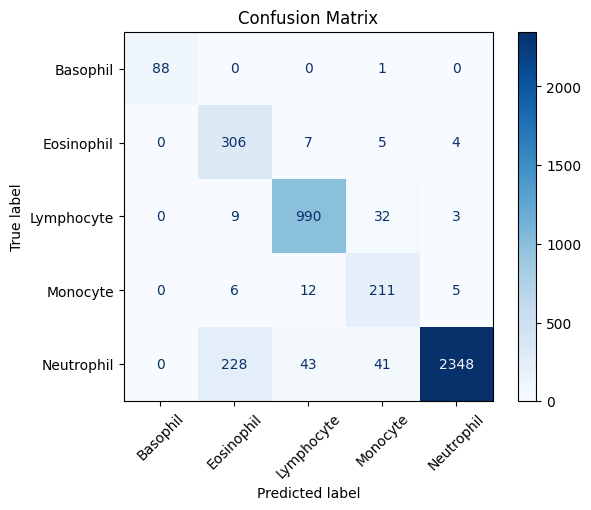

In [101]:
plot_confusion_matrix(model_cnn, DataLoader(testA_dataset, batch_size=64, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

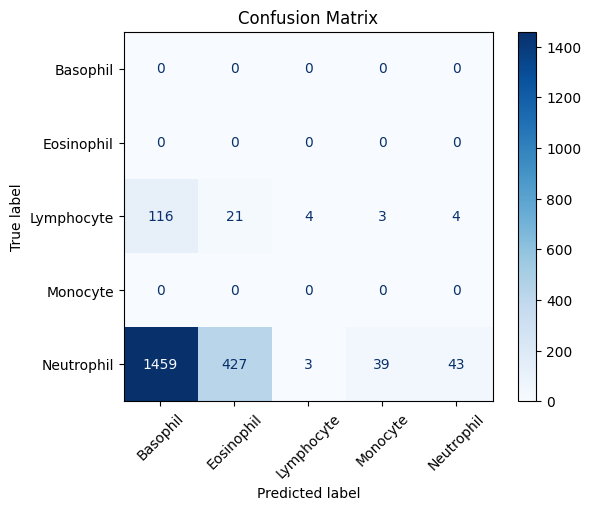

In [100]:
plot_confusion_matrix(model_cnn, DataLoader(testB_dataset, batch_size=64, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

In [107]:
print_percentage_error_classification(model_cnn, DataLoader(testA_dataset, batch_size=64, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 1.1236%
Classe: Eosinophil, Erro: 4.9689%
Classe: Lymphocyte, Erro: 4.2553%
Classe: Monocyte, Erro: 9.8291%
Classe: Neutrophil, Erro: 11.7293%


In [106]:
print_percentage_error_classification(model_cnn, DataLoader(testB_dataset, batch_size=64, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 0.0000%
Classe: Lymphocyte, Erro: 97.2973%
Classe: Monocyte, Erro: 0.0000%
Classe: Neutrophil, Erro: 97.8184%


In [115]:
del model_cnn

## resnet18

### Preparação do dataset e transfer learning

In [32]:
train_transform_resnet = v2.Compose([
    v2.ToImage(),
    AspectPreservingResizeAndPad(target_size=224, fill=255),
    ApplyCLAHE(clip_limit=2.0),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD)
])
test_transform_resnet = v2.Compose([
    v2.ToImage(),
    AspectPreservingResizeAndPad(target_size=224, fill=255),
    ApplyCLAHE(clip_limit=2.0),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD)
])


In [33]:
train_dataset_resnet = RaabinDataset(root_dir='./../datasets/raabin_wbc/Train', class_list=CLASSES_DO_PROJETO, transform=train_transform_resnet)
testA_dataset_resnet = RaabinDataset(root_dir='./../datasets/raabin_wbc/Test-A', class_list=CLASSES_DO_PROJETO, transform=test_transform_resnet)
testB_dataset_resnet = RaabinDataset(root_dir='./../datasets/raabin_wbc/Test-B', class_list=CLASSES_DO_PROJETO, transform=test_transform_resnet)

In [34]:
train_split_dataset_resnet, val_dataset_resnet = split_train_val_dataset(train_dataset_resnet, val_size=(3175/10175), random_state=SEED)

In [35]:
train_split_dataset_resnet_reduced = undersample_dataset(train_split_dataset_resnet, DataLoader(train_split_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, tamanho_undersample=2000)
val_dataset_resnet_reduced = undersample_dataset(val_dataset_resnet, DataLoader(val_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, tamanho_undersample=1000)
train_dataloader_resnet = DataLoader(train_split_dataset_resnet_reduced, batch_size=32, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
val_dataloader_resnet = DataLoader(val_dataset_resnet_reduced, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))

In [36]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, len(CLASSES_DO_PROJETO))

# Desbloquear todas as camadas para fine-tuning total
for param in model_resnet.parameters():
    param.requires_grad = True

loss_fn_resnet = nn.CrossEntropyLoss()
# Taxas de aprendizado diferenciais: 1e-5 para camadas base convolucionais, 1e-3 para fc final
optimizer_resnet = torch.optim.Adam([
    {'params': [p for name, p in model_resnet.named_parameters() if 'fc' not in name], 'lr': 1e-5},
    {'params': model_resnet.fc.parameters(), 'lr': 1e-3}
])


In [37]:
history_train_loss_resnet, history_val_loss_resnet, history_val_metric_resnet = train_model(
    model_resnet.to(device),
    train_dataloader_resnet,
    val_dataloader_resnet,
    loss_fn_resnet,
    optimizer_resnet,
    num_epochs=200,
    patience=10,
    metric_fn=f1_score_macro,
    device=device,
    verbose=True
)

Starting training for 200 epochs...
Epoch 1/200, Train Loss: 1.2251
Epoch 1/200, Validation Loss: 0.9209
Epoch 1/200, Validation Metric: 0.6921
Epoch 6/200, Train Loss: 0.5294
Epoch 6/200, Validation Loss: 0.5454
Epoch 6/200, Validation Metric: 0.8302
Epoch 11/200, Train Loss: 0.4373
Epoch 11/200, Validation Loss: 0.4680
Epoch 11/200, Validation Metric: 0.8457
Epoch 16/200, Train Loss: 0.3889
Epoch 16/200, Validation Loss: 0.4957
Epoch 16/200, Validation Metric: 0.8360
Epoch 21/200, Train Loss: 0.3742
Epoch 21/200, Validation Loss: 0.4447
Epoch 21/200, Validation Metric: 0.8452


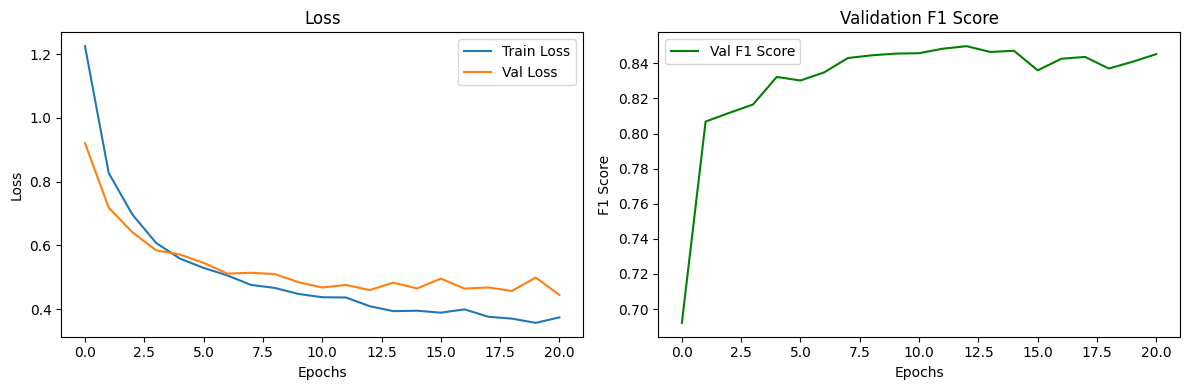

In [38]:
plot_loss_graph(history_train_loss_resnet, history_val_loss_resnet, history_val_metric_resnet)

### Avaliação nos conjuntos de teste

In [39]:
resultado_testA_resnet = evaluate_model(model_resnet.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-A com ResNet18: {resultado_testA_resnet:.4f}")

F1-Score no Test-A com ResNet18: 0.7972


In [40]:
resultado_testB_resnet = evaluate_model(model_resnet.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-B com ResNet18: {resultado_testB_resnet:.4f}")

F1-Score no Test-B com ResNet18: 0.1412


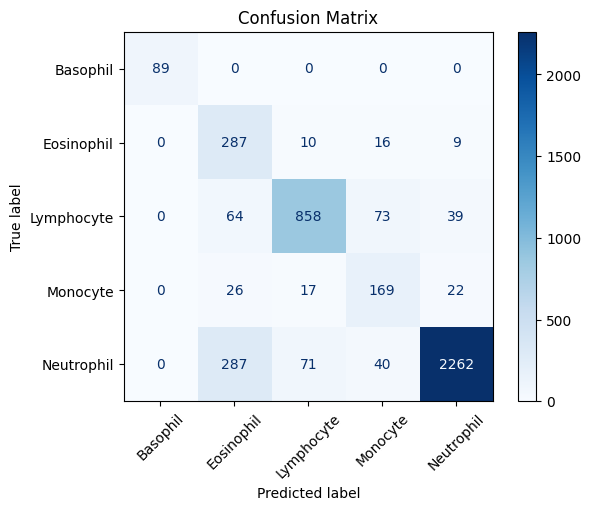

In [43]:
plot_confusion_matrix(model_resnet.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

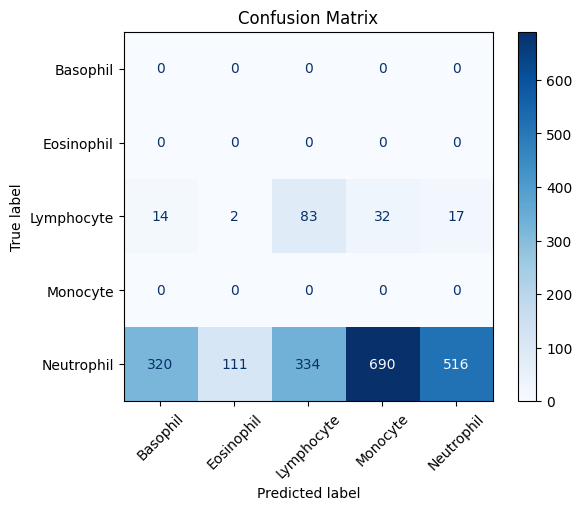

In [44]:
plot_confusion_matrix(model_resnet.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

In [45]:
print_percentage_error_classification(model_resnet.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 10.8696%
Classe: Lymphocyte, Erro: 17.0213%
Classe: Monocyte, Erro: 27.7778%
Classe: Neutrophil, Erro: 14.9624%


In [46]:
print_percentage_error_classification(model_resnet.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 0.0000%
Classe: Lymphocyte, Erro: 43.9189%
Classe: Monocyte, Erro: 0.0000%
Classe: Neutrophil, Erro: 73.8204%


In [47]:
del model_resnet

## MobileNet V3 Large 

### preparação e transfer learning do modelo

In [48]:
model_mobile_net_v3_large = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)

model_mobile_net_v3_large.classifier[3] = nn.Linear(model_mobile_net_v3_large.classifier[3].in_features, len(CLASSES_DO_PROJETO))

# Desbloquear todas as camadas para fine-tuning total
for param in model_mobile_net_v3_large.parameters():
    param.requires_grad = True

loss_fn_mobile_net_v3_large = nn.CrossEntropyLoss()
# Taxas de aprendizado diferenciais: 1e-5 para a base convolucional, 1e-3 para o classificador final
optimizer_mobile_net_v3_large = torch.optim.Adam([
    {'params': [p for name, p in model_mobile_net_v3_large.named_parameters() if 'classifier.3' not in name], 'lr': 1e-5},
    {'params': model_mobile_net_v3_large.classifier[3].parameters(), 'lr': 1e-3}
])


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/bruno/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 22.8MB/s]


In [49]:
history_train_loss_mobile_net_v3_large, history_val_loss_mobile_net_v3_large, history_val_metric_mobile_net_v3_large = train_model(
    model_mobile_net_v3_large.to(device),
    train_dataloader_resnet,
    val_dataloader_resnet,
    loss_fn_mobile_net_v3_large,
    optimizer_mobile_net_v3_large,
    num_epochs=200,
    patience=10,
    metric_fn=f1_score_macro,
    device=device,
    verbose=True
)

Starting training for 200 epochs...
Epoch 1/200, Train Loss: 1.1606
Epoch 1/200, Validation Loss: 1.3031
Epoch 1/200, Validation Metric: 0.4138
Epoch 6/200, Train Loss: 0.4178
Epoch 6/200, Validation Loss: 0.4428
Epoch 6/200, Validation Metric: 0.8766
Epoch 11/200, Train Loss: 0.3266
Epoch 11/200, Validation Loss: 0.3944
Epoch 11/200, Validation Metric: 0.8816
Epoch 16/200, Train Loss: 0.2813
Epoch 16/200, Validation Loss: 0.3722
Epoch 16/200, Validation Metric: 0.8921


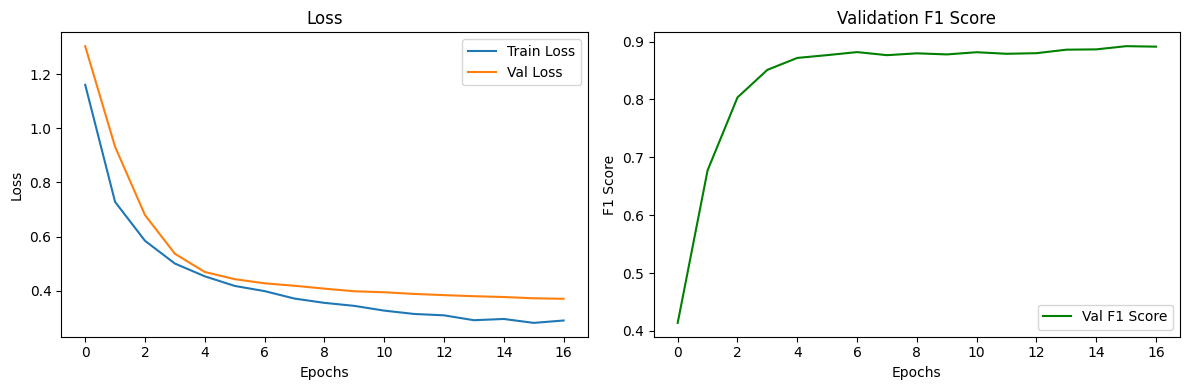

In [50]:
plot_loss_graph(history_train_loss_mobile_net_v3_large, history_val_loss_mobile_net_v3_large, history_val_metric_mobile_net_v3_large)

### Avaliação nos conjuntos de teste

In [51]:
resultado_testA_mobile_net_v3_large = evaluate_model(model_mobile_net_v3_large.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-A com MobileNetV3 Large: {resultado_testA_mobile_net_v3_large:.4f}")

F1-Score no Test-A com MobileNetV3 Large: 0.8105


In [52]:
resultado_testB_mobile_net_v3_large = evaluate_model(model_mobile_net_v3_large.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-B com MobileNetV3 Large: {resultado_testB_mobile_net_v3_large:.4f}")

F1-Score no Test-B com MobileNetV3 Large: 0.1391


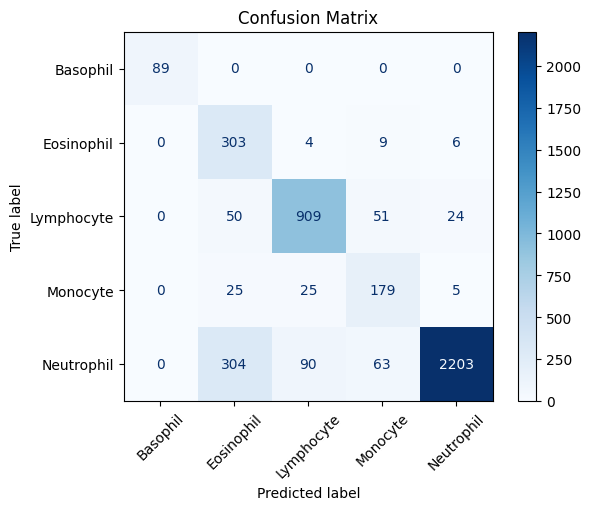

In [53]:
plot_confusion_matrix(model_mobile_net_v3_large.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

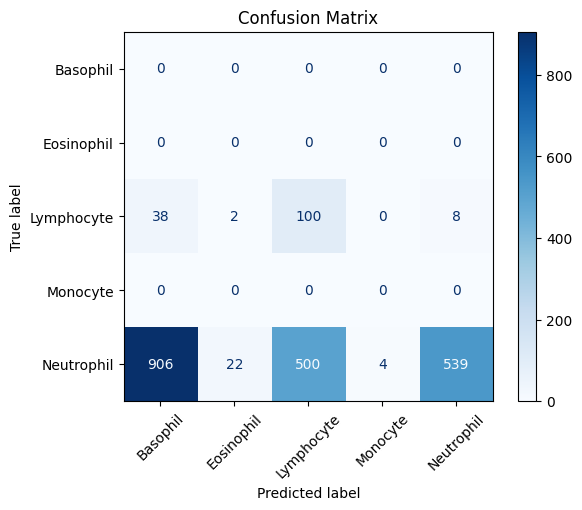

In [54]:
plot_confusion_matrix(model_mobile_net_v3_large.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

In [56]:
print_percentage_error_classification(model_mobile_net_v3_large.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 5.9006%
Classe: Lymphocyte, Erro: 12.0890%
Classe: Monocyte, Erro: 23.5043%
Classe: Neutrophil, Erro: 17.1805%


In [57]:
print_percentage_error_classification(model_mobile_net_v3_large.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 0.0000%
Classe: Lymphocyte, Erro: 32.4324%
Classe: Monocyte, Erro: 0.0000%
Classe: Neutrophil, Erro: 72.6535%


In [58]:
del model_mobile_net_v3_large

## EfficientNet-B0

### preparação e transfer learning do modelo

In [59]:
model_efficientnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

model_efficientnet_b0.classifier[1] = nn.Linear(model_efficientnet_b0.classifier[1].in_features, len(CLASSES_DO_PROJETO))

# Desbloquear todas as camadas para fine-tuning total
for param in model_efficientnet_b0.parameters():
    param.requires_grad = True

loss_fn_efficientnet_b0 = nn.CrossEntropyLoss()
# Taxas de aprendizado diferenciais: 1e-5 para a base convolucional, 1e-3 para o classificador final
optimizer_efficientnet_b0 = torch.optim.Adam([
    {'params': [p for name, p in model_efficientnet_b0.named_parameters() if 'classifier.1' not in name], 'lr': 1e-5},
    {'params': model_efficientnet_b0.classifier[1].parameters(), 'lr': 1e-3}
])


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/bruno/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 31.0MB/s]


In [60]:
history_train_loss_efficientnet_b0, history_val_loss_efficientnet_b0, history_val_metric_efficientnet_b0 = train_model(
    model_efficientnet_b0.to(device),
    train_dataloader_resnet,
    val_dataloader_resnet,
    loss_fn_efficientnet_b0,
    optimizer_efficientnet_b0,
    num_epochs=200,
    patience=10,
    metric_fn=f1_score_macro,
    device=device,
    verbose=True
)

Starting training for 200 epochs...
Epoch 1/200, Train Loss: 1.0900
Epoch 1/200, Validation Loss: 0.7987
Epoch 1/200, Validation Metric: 0.7903
Epoch 6/200, Train Loss: 0.4639
Epoch 6/200, Validation Loss: 0.4621
Epoch 6/200, Validation Metric: 0.8717
Epoch 11/200, Train Loss: 0.3803
Epoch 11/200, Validation Loss: 0.4213
Epoch 11/200, Validation Metric: 0.8757
Epoch 16/200, Train Loss: 0.3427
Epoch 16/200, Validation Loss: 0.4053
Epoch 16/200, Validation Metric: 0.8804
Epoch 21/200, Train Loss: 0.3265
Epoch 21/200, Validation Loss: 0.3897
Epoch 21/200, Validation Metric: 0.8913


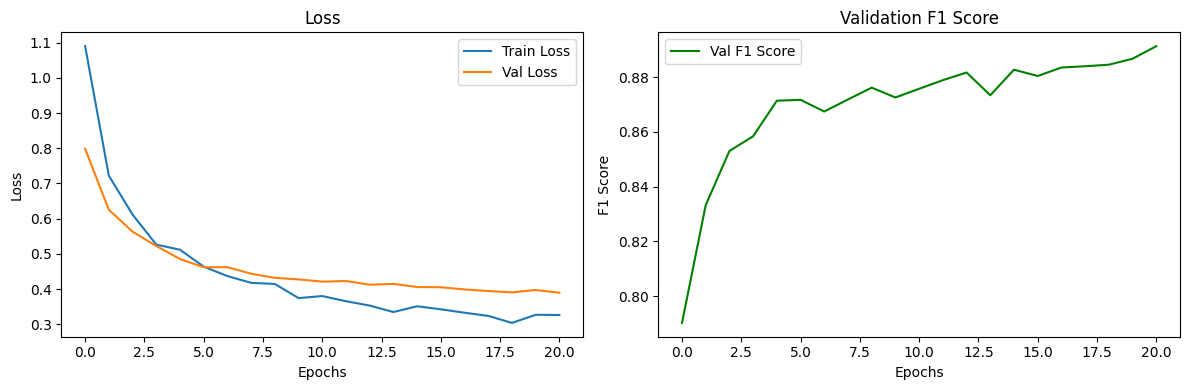

In [61]:
plot_loss_graph(history_train_loss_efficientnet_b0, history_val_loss_efficientnet_b0, history_val_metric_efficientnet_b0)

### Avaliação nos conjuntos de testes

In [69]:
resultado_testA_efficientnet_b0 = evaluate_model(model_efficientnet_b0.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-A com EfficientNetB0: {resultado_testA_efficientnet_b0:.4f}")

NameError: name 'model_efficientnet_b0' is not defined

In [63]:
resultado_testB_efficientnet_b0 = evaluate_model(model_efficientnet_b0.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), metric_fn=f1_score_macro, device=device)
print(f"F1-Score no Test-B com EfficientNetB0: {resultado_testB_efficientnet_b0:.4f}")

F1-Score no Test-B com EfficientNetB0: 0.0972


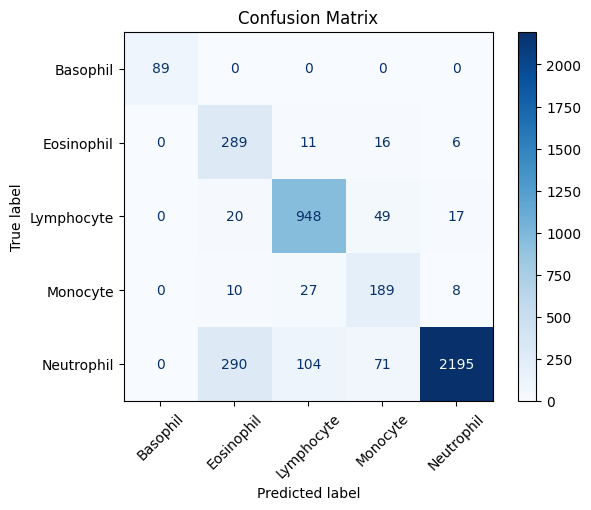

In [64]:
plot_confusion_matrix(model_efficientnet_b0.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

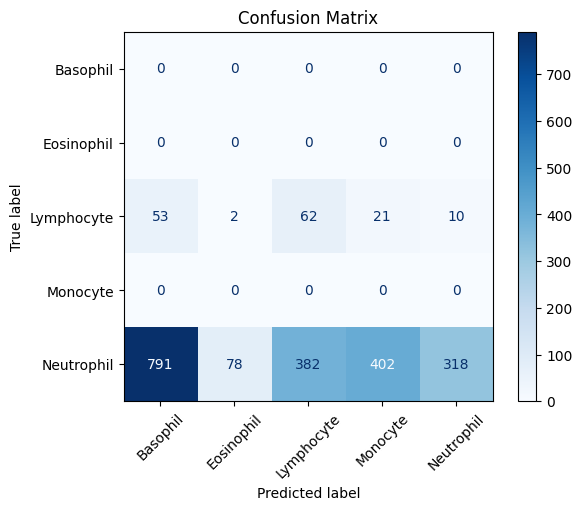

In [65]:
plot_confusion_matrix(model_efficientnet_b0.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), class_names=CLASSES_DO_PROJETO, device=device)

In [66]:
print_percentage_error_classification(model_efficientnet_b0.to(device), DataLoader(testA_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 10.2484%
Classe: Lymphocyte, Erro: 8.3172%
Classe: Monocyte, Erro: 19.2308%
Classe: Neutrophil, Erro: 17.4812%


In [67]:
print_percentage_error_classification(model_efficientnet_b0.to(device), DataLoader(testB_dataset_resnet, batch_size=32, shuffle=False), CLASSES_DO_PROJETO, device=device)

Classe: Basophil, Erro: 0.0000%
Classe: Eosinophil, Erro: 0.0000%
Classe: Lymphocyte, Erro: 58.1081%
Classe: Monocyte, Erro: 0.0000%
Classe: Neutrophil, Erro: 83.8661%


In [68]:
del model_efficientnet_b0

## Resumo e Análise Crítica

Nesta execução, conduzida com os dados brutos e sem passos complexos de pré-processamento, a estratégia adotada para lidar com o desbalanceamento de classes foi o *undersampling*. Essa escolha serviu tanto como uma solução de baixo custo computacional quanto como forma viável de operar sem carregar o dataset completo dado os recursos computacionais disponíveis.

Foram treinados e avaliados três modelos baseados em arquiteturas CNN com *Transfer Learning*: **ResNet18**, **MobileNetV3 Large** e **EfficientNet-B0**.
Além de uma CNN Base para comparação de resultados.

### Resultados (F1-Score Macro):
- **ResNet18**: Test-A = 79.72% | Test-B = 14.12%
- **MobileNetV3 Large**: Test-A = 81.05% | Test-B = 13.91%
- **EfficientNet-B0**: Test-A = 81.76% | Test-B = 9.72%
- **CNN**: Test-A = 87.74% | Test-B = 1.88%

### Análise dos Resultados

Observou-se uma discrepância drástica no desempenho dos modelos entre os dois conjuntos de teste:

1. **Conjunto Test-A (Cenário Ideal):**  
   Este conjunto é mais completo (contempla todas as classes) e suas imagens mantêm o mesmo formato (altura x largura) visto no conjunto de treinamento. Sob estas condições ideais, as CNNs pre-treinadas apresentaram excelente eficácia, superando os 80% de *f1-score*, com a CNN Base liderando no desempenho. Isso demonstra que as arquiteturas conseguiram extrair com sucesso os padrões vitais da classificação.

2. **Conjunto Test-B (Cenário com *Shift*):**  
   O cenário para o Test-B varia muito: possui dados de apenas 2 das classes e cada imagem possui formatos e dimensões originais variadas. Por conta da exigência arquitetural das CNNs, foi forçado um redimensionamento (*resize*) para padronizar a entrada. Embora o PyTorch realize interpolações sofisticadas durante o *resize*, isso demonstrou **não ser suficiente**. 
   
   A queda brusca para a faixa de ~1-14% indica que a distorção introduzida nas imagens deformou características morfológicas cruciais das células. Problemas médicos dependem fortemente da preservação das bordas e proporções (*aspect ratio*).

**Conclusão**: 
O experimento valida a capacidade dos modelos quando a distribuição e o formato padronizado dos dados persistem (Teste A). Contudo, fica evidente a fragilidade frente à variação geométrica dos dados (Teste B). Trabalhos futuros exigem um pré-processamento direcionado para mitigar isso — como a aplicação de *padding* resguardando a proporção de aspecto (*aspect ratio preserving*), em vez de redimensionamento bruto, ou *Data Augmentation* projetado especificamente para robustez espacial e dimensional.